---
authors: Freek Pols
updated: December 3, 2025
---

# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

MASSA'S
Beginmassa water:      0.4721 kg
Eindmassa water:       0.4541 kg
Verdampt water:        0.0180 kg

ENERGIE
Energie voor opwarming:  105.2 kJ
Energie voor verdamping: 40.7 kJ
TOTAAL benodigd:         145.8 kJ

AANBEVELINGEN
1. Isoleer de maatbeker om warmteverlies te beperken.
2. Meet het elektrisch vermogen van het verwarmingselement nauwkeurig.
3. Dek de beker gedeeltelijk af om verdamping te verminderen.
4. Meet ook de omgevingstemperatuur en luchtstroming.
5. Gebruik een nauwkeurige temperatuursonde.


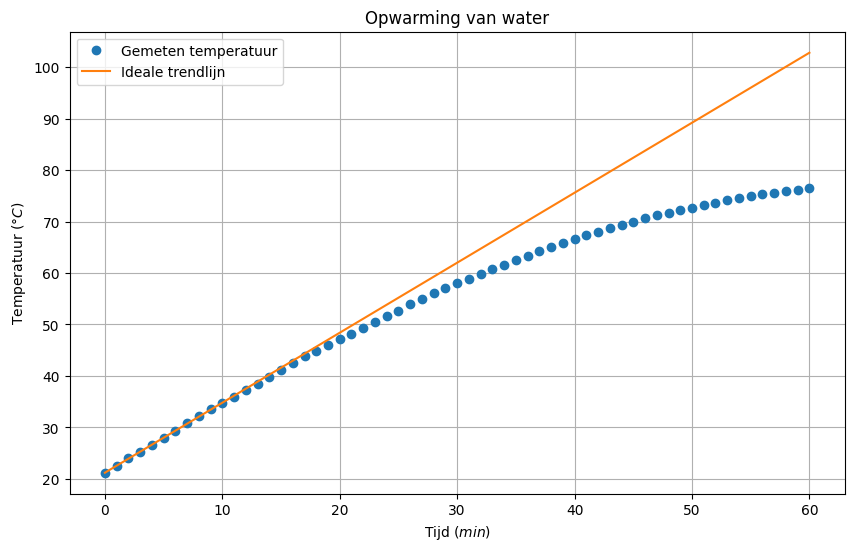

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# 1. DATA INLEZEN MET np.loadtxt

data = np.loadtxt("tempmetingen.csv", delimiter=";", skiprows=1)
t = data[:,0]
T = data[:,1]

# 2. MASSA'S EN CONSTANTEN

m_beaker = 820.8 / 1000
m_start_total = 1292.9 / 1000
m_end_total   = 1274.9 / 1000

m_water_start = m_start_total - m_beaker
m_water_end   = m_end_total   - m_beaker
m_evap        = m_water_start - m_water_end

c_water = 4180
Lv = 2.26e6

T_start = T[0]
T_end   = T[-1]


# 3. IDEALE TRENDLIJN (GEEN VERLIES, GEEN VERDAMPING)

mask = t <= 10
coeffs = np.polyfit(t[mask], T[mask], 1)
ideal_line = np.polyval(coeffs, t)


# 4. ENERGIEBEREKENING

Q_heat = m_water_end * c_water * (T_end - T_start)
Q_evap = m_evap * Lv
Q_total = Q_heat + Q_evap


# 5. RESULTATEN PRINTEN

print("MASSA'S")
print("Beginmassa water:      {:.4f} kg".format(m_water_start))
print("Eindmassa water:       {:.4f} kg".format(m_water_end))
print("Verdampt water:        {:.4f} kg".format(m_evap))
print()

print("ENERGIE")
print("Energie voor opwarming:  {:.1f} kJ".format(Q_heat/1000))
print("Energie voor verdamping: {:.1f} kJ".format(Q_evap/1000))
print("TOTAAL benodigd:         {:.1f} kJ".format(Q_total/1000))
print()

print("AANBEVELINGEN")
print("1. Isoleer de maatbeker om warmteverlies te beperken.")
print("2. Meet het elektrisch vermogen van het verwarmingselement nauwkeurig.")
print("3. Dek de beker gedeeltelijk af om verdamping te verminderen.")
print("4. Meet ook de omgevingstemperatuur en luchtstroming.")
print("5. Gebruik een nauwkeurige temperatuursonde.")


# 6. PLOT

plt.figure(figsize=(10,6))
plt.plot(t, T, 'o', label="Gemeten temperatuur")
plt.plot(t, ideal_line, '-', label="Ideale trendlijn")
plt.xlabel("Tijd ($min$)")
plt.ylabel("Temperatuur ($°C$)")
plt.title("Opwarming van water")
plt.grid(True)
plt.legend()
plt.show()